In [1]:
import requests
import bs4
import re 


def get_page(url: str) -> str:
    """
    Завантажує HTML-код сторінки за URL.
    
    Args:
        url (str): адреса сторінки
    
    Returns:
        str: HTML-код сторінки
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.0.0 Safari/537.36'
    }
    response = requests.get(url, headers=headers)
    response.encoding = 'utf-8'
    return response.text

def clean(row: str) -> str:
        """
        Очищає текст новини від службових слів, розривів рядків, ком та зайвих пробілів.
        
        Args:
            row (str): текст новини
        
        Returns:
            str: очищений текст
        """
        cleaned = row.replace("Дата публікації", "")
        cleaned = cleaned.replace("Категорія", "")
        cleaned = cleaned.replace('\n', ' ')
        cleaned = re.sub(r' +', ' ', cleaned).strip()
        cleaned = cleaned.replace(',', '')
        return cleaned


def parse_tsn(page: str):
    
    """
    Парсить HTML сторінки і знаходить елементи новин.
    
    Args:
        page (str): HTML-код сторінки
    
    Returns:
        list: список тегів <li> з класом 'l-entries__item'
    """
    soup = bs4.BeautifulSoup(page, 'lxml')
    quotes = soup.find_all('li', class_='l-entries__item')
    return [clean(q.text) for q in quotes]

def parse_korrespondent(page: str):
    """Парсить заголовки новин з ukr.net."""
    soup = bs4.BeautifulSoup(page, 'lxml')
    items = soup.find_all('div', class_='article__title')
    headlines = []
    for item in items:
        a = item.find('a')
        if a:
            headlines.append(a.text.strip())
    return [clean(h) for h in headlines]

def parse_up(page: str):
    soup = bs4.BeautifulSoup(page, 'lxml')
    items = soup.find_all('div', class_='article_title')
    headlines = []
    for item in items:
        a = item.find('a')
        if a:
            headlines.append(a.text.strip())
    return [clean(h) for h in headlines]


In [2]:
def proccess_pages(pages: int, url: str) -> str:
    """
    Завантажує HTML код декількох сторінок і об'єднує їх в один рядок.
    
    Args:
        pages (int): кількість сторінок для завантаження
        url (str): базовий URL
    
    Returns:
        str: об'єднаний HTML код всіх сторінок
    """
    page = get_page(url)
    for i in range(2, pages+1):
        page += get_page(url + f"/page-{i}")
    return page


In [3]:
tsn = parse_tsn(proccess_pages(10, "https://tsn.ua/news"))

In [4]:
ukr_pravda = parse_up(get_page("https://www.pravda.com.ua/news/"))

In [5]:
korrespondent = parse_korrespondent(get_page("https://ua.korrespondent.net/"))

In [6]:
def append(rows, path: str):
    """
    Зберігає список рядків у файл.
    
    Args:
        rows (list): список рядків для збереження
        path (str): шлях до файлу
    """
    try:
        with open(path, 'a', encoding='utf-8') as f:
            for line in rows:
                f.write(line + '\n')
    except Exception as e:
        print("Could not save the results:", e)

In [7]:
def filter_tsn(lines):
    """
    Зчитує текст з файлу та видаляє службові слова
    (наприклад, 'ТСН', 'Тема') на початку рядків.
    Повертає список очищених рядків.
    """

    for i, l in enumerate(lines):
        split = l.split()
        for _ in range(6):
            if split and (split[0] == 'ТСН' or split[0] == "Тема"):
                split.pop(0)
            if split:
                split.pop(0)
            
        lines[i] = " ".join(split)
    return [l for l in lines if l]
tsn = filter_tsn(tsn)

In [8]:
path = "result.txt"
with open(path, 'w'):
    pass
append(ukr_pravda, path)
append(korrespondent, path)
append(tsn, path)

In [9]:
def save(rows, path: str):
    """
    Зберігає список рядків у файл.
    
    Args:
        rows (list): список рядків для збереження
        path (str): шлях до файлу
    """
    try:
        with open(path, 'w', encoding='utf-8') as f:
            for line in rows:
                f.write(line + '\n')
    except Exception as e:
        print("Could not save the results:", e)

In [10]:
save(ukr_pravda, "ukr_pravda.txt")
save(tsn, "tsn.txt")
save(korrespondent, "korrespondent.txt")

In [11]:
import spacy
nlp = spacy.load("uk_core_news_sm", disable=["ner", "parser"])

In [12]:
tsn_nlp = nlp(" ".join(tsn))
kor_nlp = nlp(" ".join(korrespondent))
up_nlp = nlp(" ".join(ukr_pravda))

In [13]:
import warnings
warnings.filterwarnings("ignore")
news = [tsn_nlp, kor_nlp, up_nlp]
news_labels = ["ТСН", "Корреспондент", "Українська Правда"]
similarities = []

for n in news:
    row = []
    
    for k in news:
        row.append(n.similarity(k))
        
    similarities.append(row)
    
similarities

[[1.0, 0.9120374917984009, 0.9334263205528259],
 [0.9120374917984009, 1.0, 0.9482364654541016],
 [0.9334263205528259, 0.9482364654541016, 1.0]]

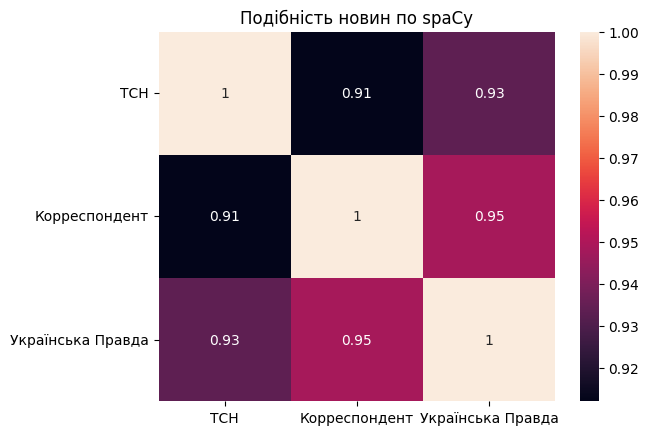

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.title("Подібність новин по spaCy")
sns.heatmap(similarities, annot=True, xticklabels=news_labels, yticklabels=news_labels)
plt.show()

In [15]:

from scipy.spatial import distance
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')




Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
model.encode(tsn)

array([[ 0.00392498,  0.08232948, -0.02659187, ...,  0.06818105,
        -0.04151434, -0.04114388],
       [-0.03120583,  0.07326668, -0.01398995, ...,  0.05463802,
        -0.01012946, -0.07293615],
       [ 0.02241456,  0.05957657, -0.05653971, ...,  0.05395393,
         0.01327962, -0.07427495],
       ...,
       [ 0.00472362, -0.01537012, -0.00898676, ..., -0.01974464,
         0.03950248, -0.03236543],
       [-0.00538625,  0.03223141, -0.05582847, ...,  0.01655846,
        -0.00306961, -0.03498851],
       [-0.08693714,  0.0411273 , -0.02274198, ...,  0.07686152,
        -0.02158346, -0.04210386]], shape=(100, 384), dtype=float32)

In [17]:
similarities = []
news = [tsn, ukr_pravda, korrespondent]

for n in news:
    row = []
    doc1 = model.encode(" ".join(n))  
    for k in news:
        doc2 = model.encode(" ".join(k)) 
        row.append(1 - distance.cosine(doc1, doc2))
    similarities.append(row)

similarities

[[np.float32(1.0), np.float32(0.79920244), np.float32(0.8522244)],
 [np.float32(0.79920244), np.float32(1.0), np.float32(0.8730178)],
 [np.float32(0.8522244), np.float32(0.8730178), np.float32(1.0)]]

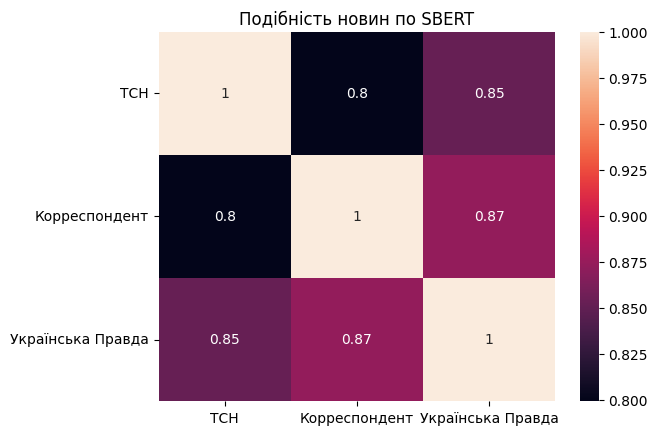

In [18]:
plt.title("Подібність новин по SBERT")
sns.heatmap(similarities, annot=True, xticklabels=news_labels, yticklabels=news_labels)
plt.show()

In [19]:
from deep_translator import GoogleTranslator
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment(headlines, source_name):
    results = {"positive": 0, "negative": 0, "neutral": 0}
    compounds = []
    
    for headline in headlines:

        translated = GoogleTranslator(source='auto', target='en').translate(headline)

        scores = analyzer.polarity_scores(translated)
        compound = scores['compound']
        compounds.append(compound)
        
        if compound > 0.3:
            results["positive"] += 1
        elif compound < -0.3:
            results["negative"] += 1
        else:
            results["neutral"] += 1
    
    avg = sum(compounds) / len(compounds)
    
    print(f"\n=== {source_name} ===")
    print(f"Позитивних: {results['positive']}")
    print(f"Негативних: {results['negative']}")
    print(f"Нейтральних: {results['neutral']}")
    print(f"Середній compound: {avg:.3f}")
    
    return results, avg

tsn_sentiment, tsn_avg = analyze_sentiment(tsn, "ТСН")
up_sentiment,  up_avg  = analyze_sentiment(ukr_pravda, "Українська правда")
kor_sentiment, kor_avg = analyze_sentiment(korrespondent, "Кореспондент")


=== ТСН ===
Позитивних: 22
Негативних: 29
Нейтральних: 49
Середній compound: -0.080

=== Українська правда ===
Позитивних: 11
Негативних: 22
Нейтральних: 37
Середній compound: -0.065

=== Кореспондент ===
Позитивних: 9
Негативних: 32
Нейтральних: 82
Середній compound: -0.100


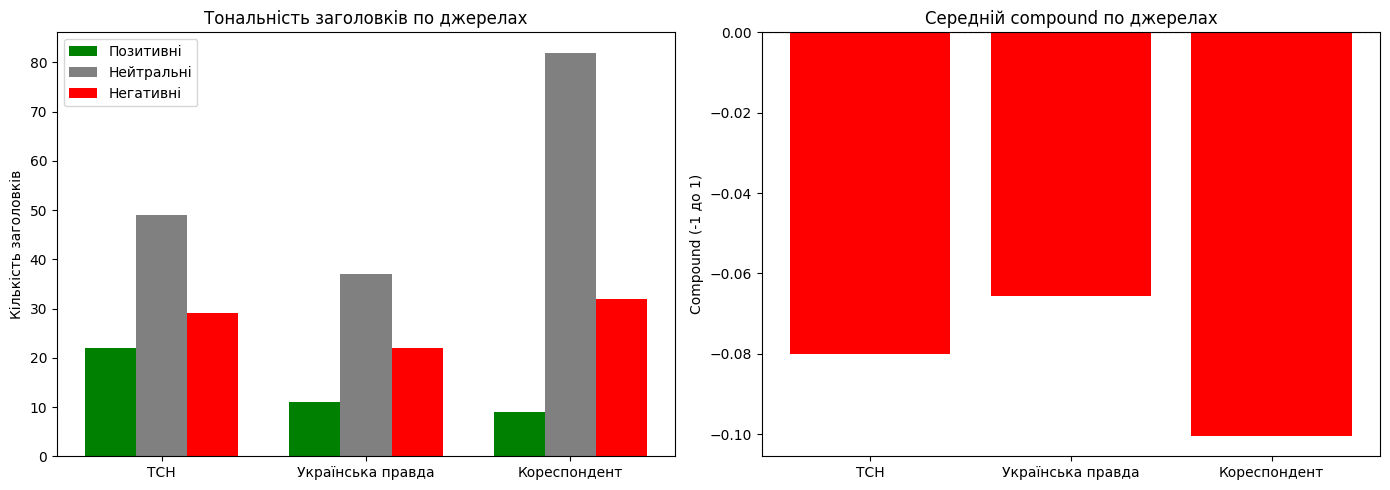

In [20]:
import matplotlib.pyplot as plt
import numpy as np

sources = ["ТСН", "Українська правда", "Кореспондент"]
sentiments = [tsn_sentiment, up_sentiment, kor_sentiment]
avgs = [tsn_avg, up_avg, kor_avg]

positive = [s["positive"] for s in sentiments]
negative = [s["negative"] for s in sentiments
neutral  = [s["neutral"]  for s in sentiments]

x = np.arange(len(sources))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width, positive, width, label="Позитивні", color="green")
axes[0].bar(x,         neutral,  width, label="Нейтральні", color="gray")
axes[0].bar(x + width, negative, width, label="Негативні",  color="red")
axes[0].set_xticks(x)
axes[0].set_xticklabels(sources)
axes[0].set_title("Тональність заголовків по джерелах")
axes[0].set_ylabel("Кількість заголовків")
axes[0].legend()

colors = ["green" if a > 0 else "red" if a < 0 else "gray" for a in avgs]
axes[1].bar(sources, avgs, color=colors)
axes[1].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Середній compound по джерелах")
axes[1].set_ylabel("Compound (-1 до 1)")

plt.tight_layout()
plt.show()